In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

pd.set_option('display.max_columns', None)

Matplotlib is building the font cache; this may take a moment.


In [2]:

df = pd.read_csv('../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv')
print("Shape:", df.shape)
df.head()

Shape: (4372, 52)


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,MaxQuantity,CustomerTenureDays,FirstPurchaseDaysAgo,PreferredDayOfWeek,PreferredHour,PreferredMonth,WeekendPurchaseRatio,AvgDaysBetweenPurchases,UniqueProducts,UniqueDescriptions,AvgProductsPerTransaction,UniqueCountries,NegativeQuantityCount,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,RegistrationDate,NewsletterSubscribed,LastLoginIP,SupportTicketsCount,SatisfactionScore,RFMSegment,AgeCategory,SpendingCategory,CustomerType,FavoriteSeason,PreferredTimeOfDay,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,-12,12,71,374,3,9,12,0.000000,0.221865,24,25,0.685714,1,15,0,15,0.048077,312,35,8.914286,NaN,17/07/10,Yes,59.252.219.201,1.0,4.0,Fidèles,Inconnu,VIP,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,-3,32,342,374,2,13,10,0.168367,1.717949,106,106,5.888889,1,24,0,24,0.122449,196,18,10.888889,NaN,2010-10-04,Yes,77.255.247.14,3.0,4.0,Champions,Inconnu,VIP,Régulier,Automne,Midi,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,-36,360,370,374,4,12,11,0.055777,1.456000,115,117,6.388889,1,4,0,4,0.015936,251,18,13.944444,46.0,12/09/2009,Yes,51.139.78.80,2.0,5.0,Champions,45-54,VIP,Hyperactif,Automne,Midi,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,1,80,278,374,0,9,9,0.000000,10.259259,24,24,4.800000,1,0,0,0,0.000000,28,5,5.600000,32.0,28/01/10,Yes,10.212.80.124,2.0,2.0,Potentiels,25-34,High,Nouveau,Automne,Matin,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,-12,32,43,374,2,9,12,0.000000,8.200000,1,1,0.166667,1,3,0,3,0.500000,6,6,1.000000,NaN,2009-12-10,Yes,186.34.121.80,2.0,1.0,Potentiels,Inconnu,High,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


In [3]:
print("=== INFOS GENERALES ===")
df.info()

print("\n=== STATISTIQUES DESCRIPTIVES ===")
df.describe()

=== INFOS GENERALES ===
<class 'pandas.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 4372 non-null   int64  
 1   Recency                    4372 non-null   int64  
 2   Frequency                  4372 non-null   int64  
 3   MonetaryTotal              4372 non-null   float64
 4   MonetaryAvg                4372 non-null   float64
 5   MonetaryStd                4372 non-null   float64
 6   MonetaryMin                4372 non-null   float64
 7   MonetaryMax                4372 non-null   float64
 8   TotalQuantity              4372 non-null   int64  
 9   AvgQuantityPerTransaction  4372 non-null   float64
 10  MinQuantity                4372 non-null   int64  
 11  MaxQuantity                4372 non-null   int64  
 12  CustomerTenureDays         4372 non-null   int64  
 13  FirstPurchaseDaysAgo       4372 non

,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,MaxQuantity,CustomerTenureDays,FirstPurchaseDaysAgo,PreferredDayOfWeek,PreferredHour,PreferredMonth,WeekendPurchaseRatio,AvgDaysBetweenPurchases,UniqueProducts,UniqueDescriptions,AvgProductsPerTransaction,UniqueCountries,NegativeQuantityCount,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,SupportTicketsCount,SatisfactionScore,Churn
count,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4293.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,3061.000000,4372.000000,4372.000000,4372.000000
mean,15299.677722,92.047118,5.075480,1898.459701,28.839013,88.672383,-86.425754,185.179522,1122.344007,22.389288,-37.791171,120.427264,133.385865,225.779048,2.535910,12.486962,7.605215,0.130127,3.401035,61.211116,61.563815,16.642622,1.001830,2.036825,0.009149,2.036825,0.032045,93.053294,5.075480,19.883969,49.149951,21.778591,5.328225,0.332571
std,1722.390705,100.765435,9.338754,8219.345141,127.323926,2689.001161,2876.398935,2881.283699,4672.790720,213.257466,1681.542061,1684.685799,132.845467,118.412473,1.841548,2.310701,3.480330,0.276888,11.485343,85.425119,86.293362,16.029633,0.042742,7.340449,0.126218,7.340449,0.107003,232.471608,9.338754,18.512016,18.267835,139.267307,15.410883,0.471188
min,12346.000000,1.000000,1.000000,-4287.630000,-4287.630000,0.000000,-168469.600000,-4287.630000,-303.000000,-144.000000,-80995.000000,-144.000000,0.000000,1.000000,0.000000,7.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.166667,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,18.000000,-1.000000,-1.000000,0.000000
25%,13812.750000,17.000000,1.000000,293.362500,10.985960,6.226414,-11.500000,31.800000,153.000000,5.475745,-2.000000,24.000000,0.000000,115.000000,1.000000,11.000000,5.000000,0.000000,0.000000,15.000000,15.000000,6.500000,1.000000,0.000000,0.000000,0.000000,0.000000,17.000000,1.000000,8.000000,34.000000,1.000000,2.000000,0.000000
50%,15300.500000,50.000000,3.000000,648.075000,16.918616,10.349780,0.790000,52.020000,365.000000,9.494392,1.000000,36.000000,97.500000,253.000000,2.000000,12.000000,9.000000,0.000000,1.150000,35.000000,35.000000,12.000000,1.000000,0.000000,0.000000,0.000000,0.000000,42.000000,3.000000,14.600000,49.000000,2.000000,3.000000,0.000000
75%,16778.250000,143.000000,5.000000,1611.725000,23.542941,20.629858,6.960000,102.000000,962.250000,14.008333,2.000000,72.000000,255.250000,332.000000,4.000000,14.000000,11.000000,0.083333,3.053097,77.000000,77.000000,21.511364,1.000000,1.000000,0.000000,1.000000,0.021009,102.000000,5.000000,25.212500,65.000000,3.000000,4.000000,1.000000
max,18287.000000,374.000000,248.000000,279489.020000,3861.000000,137554.852393,3861.000000,168469.600000,196719.000000,12540.000000,12540.000000,80995.000000,373.000000,374.000000,6.000000,20.000000,12.000000,1.000000,309.000000,1794.000000,1824.000000,219.000000,2.000000,226.000000,4.000000,226.000000,1.000000,7983.000000,248.000000,219.000000,80.000000,999.000000,99.000000,1.000000


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Manquants': missing,
    'Pourcentage': missing_pct
}).sort_values('Pourcentage', ascending=False)

print(missing_df[missing_df['Manquants'] > 0])

                         Manquants  Pourcentage
Age                           1311    29.986276
AvgDaysBetweenPurchases         79     1.806953


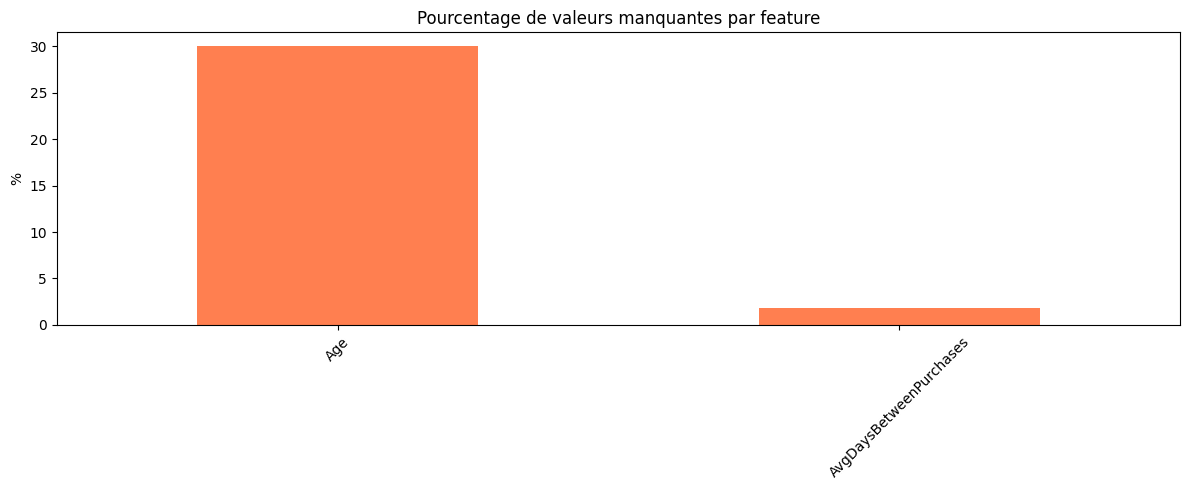

In [5]:
plt.figure(figsize=(12, 5))
missing_df[missing_df['Manquants'] > 0]['Pourcentage'].plot(kind='bar', color='coral')
plt.title('Pourcentage de valeurs manquantes par feature')
plt.ylabel('%')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/missing_values.png')
plt.show()

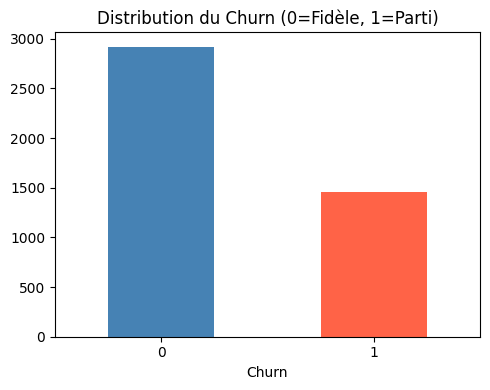

In [6]:
plt.figure(figsize=(5, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Distribution du Churn (0=Fidèle, 1=Parti)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/churn_distribution.png')
plt.show()

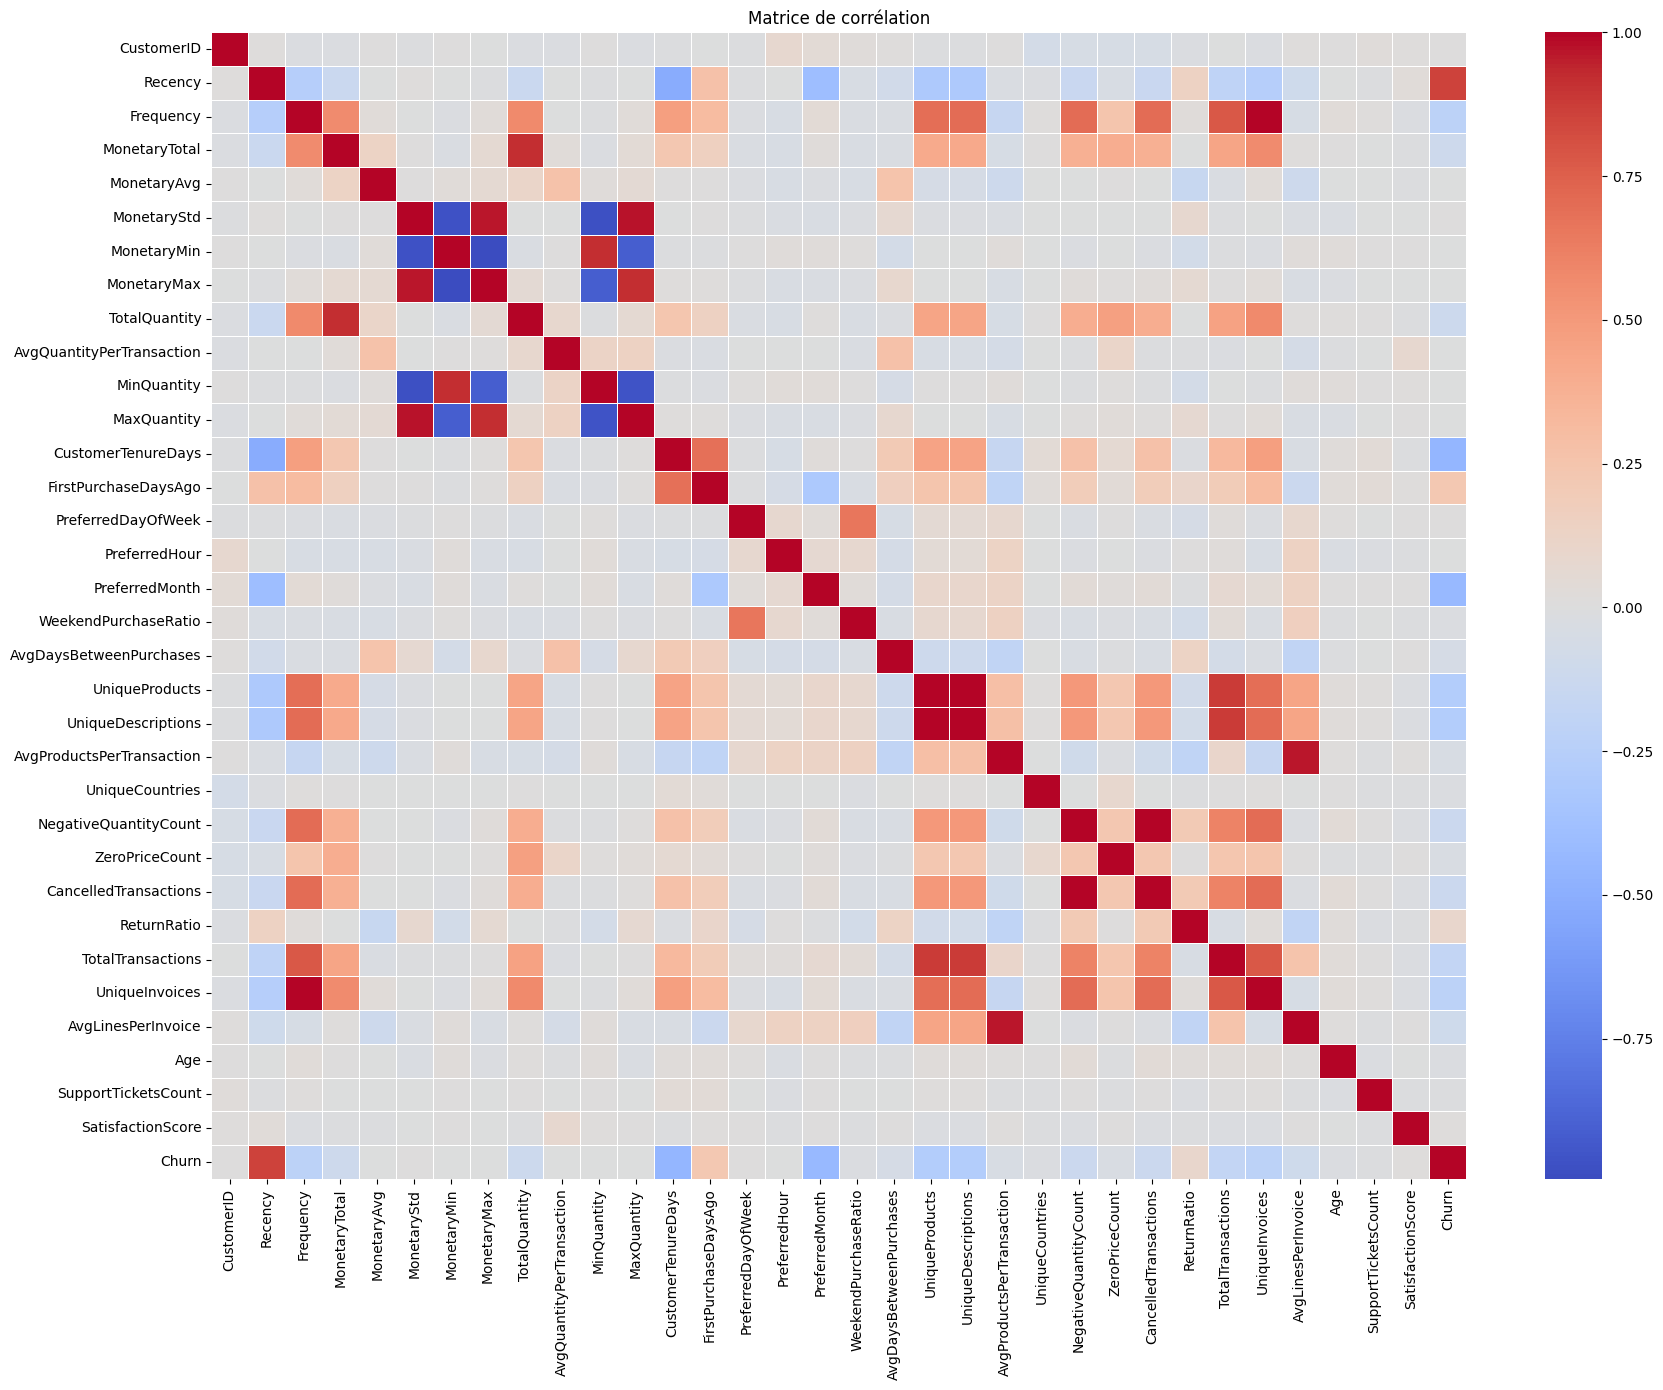

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png')
plt.show()

SupportTicketsCount uniques: [  1.   3.   2.  -1.   4. 999.   6.   0.   5.   7.   9.   8.]
SatisfactionScore uniques: [ 4.  5.  2.  1.  3. -1.  0. 99.]


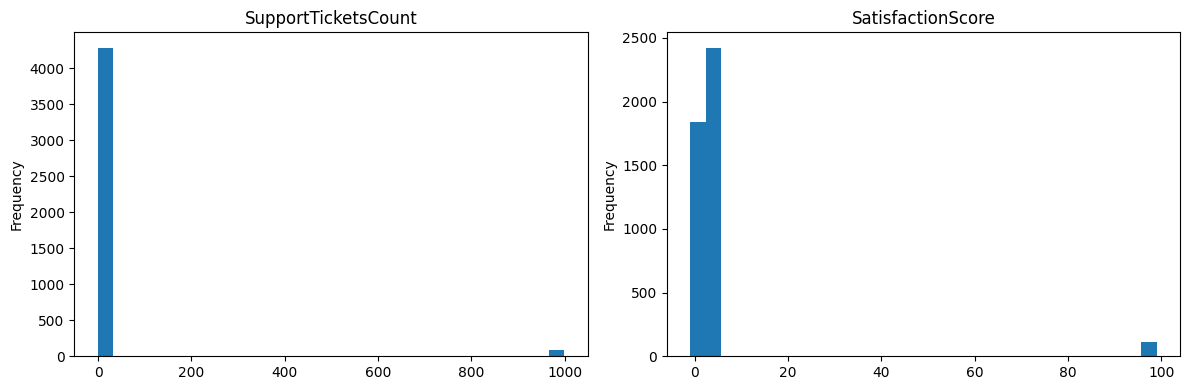

In [9]:
# Valeurs aberrantes : SupportTicketsCount et SatisfactionScore
print("SupportTicketsCount uniques:", df['SupportTicketsCount'].unique())
print("SatisfactionScore uniques:", df['SatisfactionScore'].unique())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['SupportTicketsCount'].plot(kind='hist', ax=axes[0], bins=30, title='SupportTicketsCount')
df['SatisfactionScore'].plot(kind='hist', ax=axes[1], bins=30, title='SatisfactionScore')
plt.tight_layout()
plt.savefig('../reports/outliers_support_satisfaction.png')
plt.show()